# HEIC to TIFF Model Evaluation

This notebook evaluates the trained UNet3D model for HEIC to TIFF translation:
- Load trained model checkpoint
- Compute SSIM and PSNR metrics
- Visualize reconstructions
- Generate statistics and comparisons

In [1]:
try:
    import pandas as pd
    import seaborn as sns    
except ImportError:
    !pip install pandas
    !pip install seaborn

In [2]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import pandas as pd
import seaborn as sns
import lovely_tensors as lt
lt.monkey_patch()

# Image quality metrics
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Add project root to path
sys.path.append('/myhome/sdate')

from sdate.datasets import TiffVolumeDataset
from sdate.training.compression.train_heic_to_tiff import PositionalEncoder
from diffusers import UNet3DConditionModel

# Set style for better plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)

print("Libraries imported successfully!")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## 1. Configuration and Setup

In [6]:
# Configuration
config = {
    # Data configuration
    'data_path': '/myhome/data/sdate/shared/compression_paper/file_3_extracted',
    'checkpoint_path': '../heic_training_outputs/checkpoint-2784',  # Adjust to your checkpoint
    
    # Volume configuration (must match training)
    'volume_size': 32,
    'stride': 32,
    'num_frames': 32,  # Use all frames from training
    'heic_quality': 50,
    
    # Evaluation configuration
    'batch_size': 8,
    'max_workers': 8,  # For parallel SSIM computation
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    # Metric configuration
    'data_range': 1.0,  # Assuming normalized data [0, 1]
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  data_path: /myhome/data/sdate/shared/compression_paper/file_3_extracted
  checkpoint_path: ../heic_training_outputs/checkpoint-2784
  volume_size: 32
  stride: 32
  num_frames: 32
  heic_quality: 50
  batch_size: 8
  max_workers: 8
  device: cuda
  data_range: 1.0


## 2. Load Dataset

In [7]:
print("Loading dataset with dual-channel data (TIFF + HEIC)...")

dataset = TiffVolumeDataset(
    data_path=config['data_path'],
    volume_size=config['volume_size'],
    stride=config['stride'],
    num_frames=config['num_frames'],
    start_offset=0,
    normalize=True,
    global_normalize=True,
    use_heic_compression=True,
    heic_quality=config['heic_quality'],
    dual_channel=True,
    max_workers=config['max_workers'],
)

print(f"\nDataset loaded:")
print(f"  Total sub-volumes: {len(dataset)}")
print(f"  Full volume shape: {dataset.volume.shape}")
print(f"  Sub-volume size: {config['volume_size']}x{config['volume_size']}x{config['volume_size']}")
print(f"  Value range: [{dataset.global_min:.2f}, {dataset.global_max:.2f}]")

Loading dataset with dual-channel data (TIFF + HEIC)...
Loading 32 TIFF frames from /myhome/data/sdate/shared/compression_paper/file_3_extracted
HEIC compression enabled (quality=50, dual_channel=True)
  Loading frames 0 to 31 (32 files)


Loading TIFF files: 100%|██████████| 32/32 [00:00<00:00, 436.92files/s]


  All HEIC files already exist, loading...


Loading HEIC files: 100%|██████████| 32/32 [00:00<00:00, 51.41files/s]


  Created dual-channel volume: TIFF + HEIC
  Volume loaded: shape=torch.Size([32, 2, 1900, 1008]), dtype=torch.float32
  Value range: [0.00, 255.00]
  Sub-volumes per dimension: D=1, H=60, W=32
Created TiffVolumeDataset:
  Volume shape: torch.Size([32, 2, 1900, 1008])
  Sub-volume size: 32x32x32
  Stride: 32
  Number of sub-volumes: 1920
  Dataset length: 1920

Dataset loaded:
  Total sub-volumes: 1920
  Full volume shape: torch.Size([32, 2, 1900, 1008])
  Sub-volume size: 32x32x32
  Value range: [0.00, 255.00]


## 3. Load Trained Model

In [8]:
print("Loading trained model...")

checkpoint_path = Path(config['checkpoint_path'])

if not checkpoint_path.exists():
    print(f"\nCheckpoint not found at: {checkpoint_path}")
    print("\nAvailable checkpoints:")
    output_dir = checkpoint_path.parent
    if output_dir.exists():
        checkpoints = sorted(output_dir.glob('checkpoint-*'))
        for cp in checkpoints:
            print(f"  - {cp}")
        if checkpoints:
            print(f"\nUsing latest checkpoint: {checkpoints[-1]}")
            checkpoint_path = checkpoints[-1]
    else:
        raise FileNotFoundError(f"Output directory not found: {output_dir}")

# Load UNet3D model
model = UNet3DConditionModel.from_pretrained(checkpoint_path / "unet")
model = model.to(config['device'])
model.eval()

print(f"✓ Model loaded from {checkpoint_path}")
print(f"  Device: {config['device']}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Load positional encoder
positional_encoder = PositionalEncoder(
    d_model=768,
    max_position=max(1000, config['volume_size'] * 4)
)

pos_encoder_path = checkpoint_path / "positional_encoder.pth"
if pos_encoder_path.exists():
    positional_encoder.load_state_dict(torch.load(pos_encoder_path))
    print("✓ Positional encoder loaded")
else:
    print("⚠ Positional encoder not found, using initialized version")

positional_encoder = positional_encoder.to(config['device'])
positional_encoder.eval()

print("\nModel ready for evaluation!")

Loading trained model...
✓ Model loaded from ../heic_training_outputs/checkpoint-2784
  Device: cuda
  Parameters: 121,505,473
✓ Positional encoder loaded

Model ready for evaluation!


## 4. Run Inference on All Sub-volumes

In [9]:
print("Running inference on all sub-volumes...")
print(f"Processing {len(dataset)} sub-volumes with batch size {config['batch_size']}")

# Storage for results
predictions = []
targets = []
inputs = []
positions_list = []

# Create batches manually for better control
num_batches = (len(dataset) + config['batch_size'] - 1) // config['batch_size']

with torch.no_grad():
    for batch_idx in tqdm(range(num_batches), desc="Inference"):
        start_idx = batch_idx * config['batch_size']
        end_idx = min(start_idx + config['batch_size'], len(dataset))
        
        # Load batch
        batch_volumes = []
        batch_positions = []
        
        for idx in range(start_idx, end_idx):
            dual_volume, position = dataset[idx]
            batch_volumes.append(dual_volume)
            batch_positions.append(position)
        
        # Stack into batch
        batch_volumes = torch.stack(batch_volumes)  # (B, 2, D, H, W)
        batch_positions = torch.stack(batch_positions)  # (B, 3)
        
        # Split channels
        tiff_volumes = batch_volumes[:, 0:1]  # (B, 1, D, H, W) - target
        heic_volumes = batch_volumes[:, 1:2]  # (B, 1, D, H, W) - input
        
        # Move to device
        heic_volumes = heic_volumes.to(config['device'])
        batch_positions = batch_positions.to(config['device'])
        
        # Generate positional encodings
        encoder_hidden_states = positional_encoder(batch_positions)  # (B, 768)
        encoder_hidden_states = encoder_hidden_states.unsqueeze(1)  # (B, 1, 768)

        combined_inputs = torch.cat([heic_volumes, torch.zeros_like(heic_volumes)], dim=1)
        
        # Run model
        predicted_tiff = model(
            sample=combined_inputs,
            timestep=torch.zeros(heic_volumes.shape[0], device=config['device']),
            encoder_hidden_states=encoder_hidden_states,
        ).sample
        
        # Store results (move back to CPU)
        predictions.append(predicted_tiff.cpu())
        targets.append(tiff_volumes)
        inputs.append(heic_volumes.cpu())
        positions_list.append(batch_positions.cpu())

# Concatenate all batches
predictions = torch.cat(predictions, dim=0)  # (N, 1, D, H, W)
targets = torch.cat(targets, dim=0)  # (N, 1, D, H, W)
inputs = torch.cat(inputs, dim=0)  # (N, 1, D, H, W)
positions_list = torch.cat(positions_list, dim=0)  # (N, 3)

print(f"\nInference complete!")
print(f"  Predictions shape: {predictions.shape}")
print(f"  Targets shape: {targets.shape}")
print(f"  Inputs shape: {inputs.shape}")
print(f"  Prediction value range: [{predictions.min():.4f}, {predictions.max():.4f}]")
print(f"  Target value range: [{targets.min():.4f}, {targets.max():.4f}]")

Running inference on all sub-volumes...
Processing 1920 sub-volumes with batch size 8


Inference:   0%|          | 0/240 [00:01<?, ?it/s]


RuntimeError: Given groups=1, weight of size [64, 1, 3, 3], expected input[256, 2, 32, 32] to have 1 channels, but got 2 channels instead

## 5. Compute SSIM and PSNR Metrics (Parallelized)

In [15]:
def compute_slice_metrics(args):
    """
    Compute SSIM and PSNR for a single 2D slice.
    
    Args:
        args: Tuple of (pred_slice, target_slice, data_range, slice_idx)
    
    Returns:
        Dict with slice_idx, ssim, and psnr values
    """
    pred_slice, target_slice, data_range, slice_idx = args
    
    # Compute SSIM
    ssim_value = ssim(
        target_slice,
        pred_slice,
        data_range=data_range
    )
    
    # Compute PSNR
    psnr_value = psnr(
        target_slice,
        pred_slice,
        data_range=data_range
    )
    
    return {
        'slice_idx': slice_idx,
        'ssim': ssim_value,
        'psnr': psnr_value
    }


print("Computing SSIM and PSNR metrics slice by slice...")
print(f"Using {config['max_workers']} parallel workers")

# Prepare data for parallel processing
# We'll compute metrics for each slice in each sub-volume
slice_args = []

# Convert to numpy for skimage
predictions_np = predictions.squeeze(1).numpy()  # (N, D, H, W)
targets_np = targets.squeeze(1).numpy()  # (N, D, H, W)
inputs_np = inputs.squeeze(1).numpy()  # (N, D, H, W)

# Calculate data range (difference between max and min values)
data_range = max(targets_np.max() - targets_np.min(), 1e-8)
print(f"Data range for metrics: {data_range:.4f}")

# Create arguments for all slices across all sub-volumes
total_slices = 0
for vol_idx in range(len(predictions_np)):
    for slice_idx in range(predictions_np.shape[1]):
        pred_slice = predictions_np[vol_idx, slice_idx]
        target_slice = targets_np[vol_idx, slice_idx]
        
        slice_args.append((
            pred_slice,
            target_slice,
            data_range,
            (vol_idx, slice_idx)
        ))
        total_slices += 1

print(f"Total slices to process: {total_slices:,}")

# Compute metrics in parallel
slice_metrics = []

with ProcessPoolExecutor(max_workers=config['max_workers']) as executor:
    futures = {executor.submit(compute_slice_metrics, args): i 
               for i, args in enumerate(slice_args)}
    
    for future in tqdm(as_completed(futures), total=len(futures), desc="Computing metrics"):
        try:
            result = future.result()
            slice_metrics.append(result)
        except Exception as e:
            print(f"Error processing slice: {e}")

print(f"\n✓ Computed metrics for {len(slice_metrics):,} slices")

Computing SSIM and PSNR metrics slice by slice...
Using 8 parallel workers
Data range for metrics: 0.4745
Total slices to process: 61,440
Total slices to process: 61,440


Computing metrics: 100%|██████████| 61440/61440 [00:24<00:00, 2541.42it/s]




✓ Computed metrics for 61,440 slices


## 6. Compute Metrics: HEIC vs Predicted TIFF

In [16]:
print("Computing baseline metrics (HEIC vs Target TIFF)...")

# Compute HEIC baseline metrics
heic_slice_args = []

for vol_idx in range(len(inputs_np)):
    for slice_idx in range(inputs_np.shape[1]):
        heic_slice = inputs_np[vol_idx, slice_idx]
        target_slice = targets_np[vol_idx, slice_idx]
        
        heic_slice_args.append((
            heic_slice,
            target_slice,
            data_range,
            (vol_idx, slice_idx)
        ))

heic_metrics = []

with ProcessPoolExecutor(max_workers=config['max_workers']) as executor:
    futures = {executor.submit(compute_slice_metrics, args): i 
               for i, args in enumerate(heic_slice_args)}
    
    for future in tqdm(as_completed(futures), total=len(futures), desc="Computing HEIC metrics"):
        try:
            result = future.result()
            heic_metrics.append(result)
        except Exception as e:
            print(f"Error processing HEIC slice: {e}")

print(f"✓ Computed HEIC baseline metrics for {len(heic_metrics):,} slices")

Computing baseline metrics (HEIC vs Target TIFF)...


Computing HEIC metrics: 100%|██████████| 61440/61440 [00:25<00:00, 2414.77it/s]



✓ Computed HEIC baseline metrics for 61,440 slices


## 7. Statistical Analysis

In [17]:
# Convert to DataFrames for analysis
df_predicted = pd.DataFrame(slice_metrics)
df_predicted['method'] = 'Predicted'

df_heic = pd.DataFrame(heic_metrics)
df_heic['method'] = 'HEIC'

# Combine for comparison
df_combined = pd.concat([df_predicted, df_heic], ignore_index=True)

print("="*80)
print("METRIC STATISTICS")
print("="*80)

print("\n📊 Predicted TIFF (Model Output) vs Target TIFF:")
print("-" * 80)
print(df_predicted[['ssim', 'psnr']].describe())

print("\n📊 HEIC (Compressed Input) vs Target TIFF:")
print("-" * 80)
print(df_heic[['ssim', 'psnr']].describe())

print("\n📈 IMPROVEMENT STATISTICS:")
print("-" * 80)
ssim_improvement = df_predicted['ssim'].mean() - df_heic['ssim'].mean()
psnr_improvement = df_predicted['psnr'].mean() - df_heic['psnr'].mean()

print(f"Average SSIM - Predicted: {df_predicted['ssim'].mean():.6f}")
print(f"Average SSIM - HEIC:      {df_heic['ssim'].mean():.6f}")
print(f"SSIM Improvement:         {ssim_improvement:.6f} ({ssim_improvement/df_heic['ssim'].mean()*100:.2f}%)")
print()
print(f"Average PSNR - Predicted: {df_predicted['psnr'].mean():.4f} dB")
print(f"Average PSNR - HEIC:      {df_heic['psnr'].mean():.4f} dB")
print(f"PSNR Improvement:         {psnr_improvement:.4f} dB ({psnr_improvement/df_heic['psnr'].mean()*100:.2f}%)")

METRIC STATISTICS

📊 Predicted TIFF (Model Output) vs Target TIFF:
--------------------------------------------------------------------------------
               ssim          psnr
count  61440.000000  61440.000000
mean       0.863142     20.849550
std        0.067406      0.656137
min       -0.392794     16.275074
25%        0.863096     20.608494
50%        0.873491     20.928319
75%        0.882630     21.221326
max        0.908959     22.859940

📊 HEIC (Compressed Input) vs Target TIFF:
--------------------------------------------------------------------------------
               ssim          psnr
count  61440.000000  61440.000000
mean       0.535111      3.199137
std        0.030440      1.796965
min        0.380748      1.755794
25%        0.526205      2.509433
50%        0.537857      2.821337
75%        0.549812      3.256928
max        0.610883     19.167405

📈 IMPROVEMENT STATISTICS:
--------------------------------------------------------------------------------
Average 

## 8. Visualization: Metric Distributions

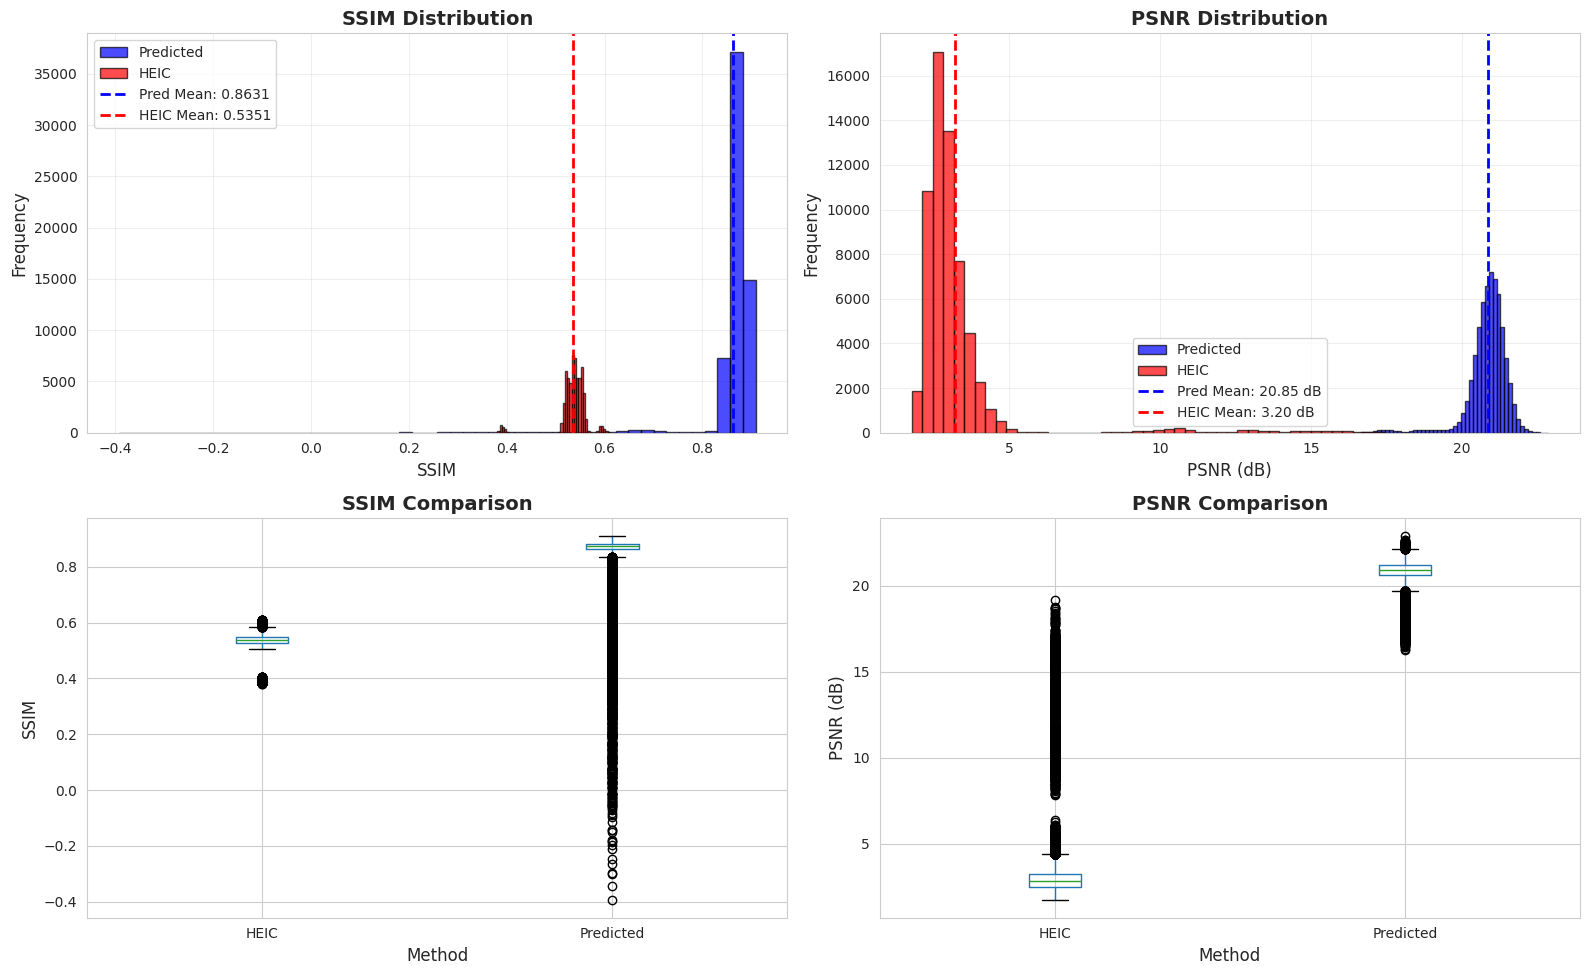

✓ Metric distributions saved to 'heic_to_tiff_metrics_distribution.png'


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# SSIM Distribution
axes[0, 0].hist(df_predicted['ssim'], bins=50, alpha=0.7, label='Predicted', color='blue', edgecolor='black')
axes[0, 0].hist(df_heic['ssim'], bins=50, alpha=0.7, label='HEIC', color='red', edgecolor='black')
axes[0, 0].axvline(df_predicted['ssim'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Pred Mean: {df_predicted["ssim"].mean():.4f}')
axes[0, 0].axvline(df_heic['ssim'].mean(), color='red', linestyle='--', linewidth=2, label=f'HEIC Mean: {df_heic["ssim"].mean():.4f}')
axes[0, 0].set_xlabel('SSIM', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('SSIM Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# PSNR Distribution
axes[0, 1].hist(df_predicted['psnr'], bins=50, alpha=0.7, label='Predicted', color='blue', edgecolor='black')
axes[0, 1].hist(df_heic['psnr'], bins=50, alpha=0.7, label='HEIC', color='red', edgecolor='black')
axes[0, 1].axvline(df_predicted['psnr'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Pred Mean: {df_predicted["psnr"].mean():.2f} dB')
axes[0, 1].axvline(df_heic['psnr'].mean(), color='red', linestyle='--', linewidth=2, label=f'HEIC Mean: {df_heic["psnr"].mean():.2f} dB')
axes[0, 1].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)

# Box plots
df_combined.boxplot(column='ssim', by='method', ax=axes[1, 0])
axes[1, 0].set_xlabel('Method', fontsize=12)
axes[1, 0].set_ylabel('SSIM', fontsize=12)
axes[1, 0].set_title('SSIM Comparison', fontsize=14, fontweight='bold')
axes[1, 0].get_figure().suptitle('')  # Remove default title

df_combined.boxplot(column='psnr', by='method', ax=axes[1, 1])
axes[1, 1].set_xlabel('Method', fontsize=12)
axes[1, 1].set_ylabel('PSNR (dB)', fontsize=12)
axes[1, 1].set_title('PSNR Comparison', fontsize=14, fontweight='bold')
axes[1, 1].get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig('heic_to_tiff_metrics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metric distributions saved to 'heic_to_tiff_metrics_distribution.png'")

## 9. Visualization: Sample Reconstructions

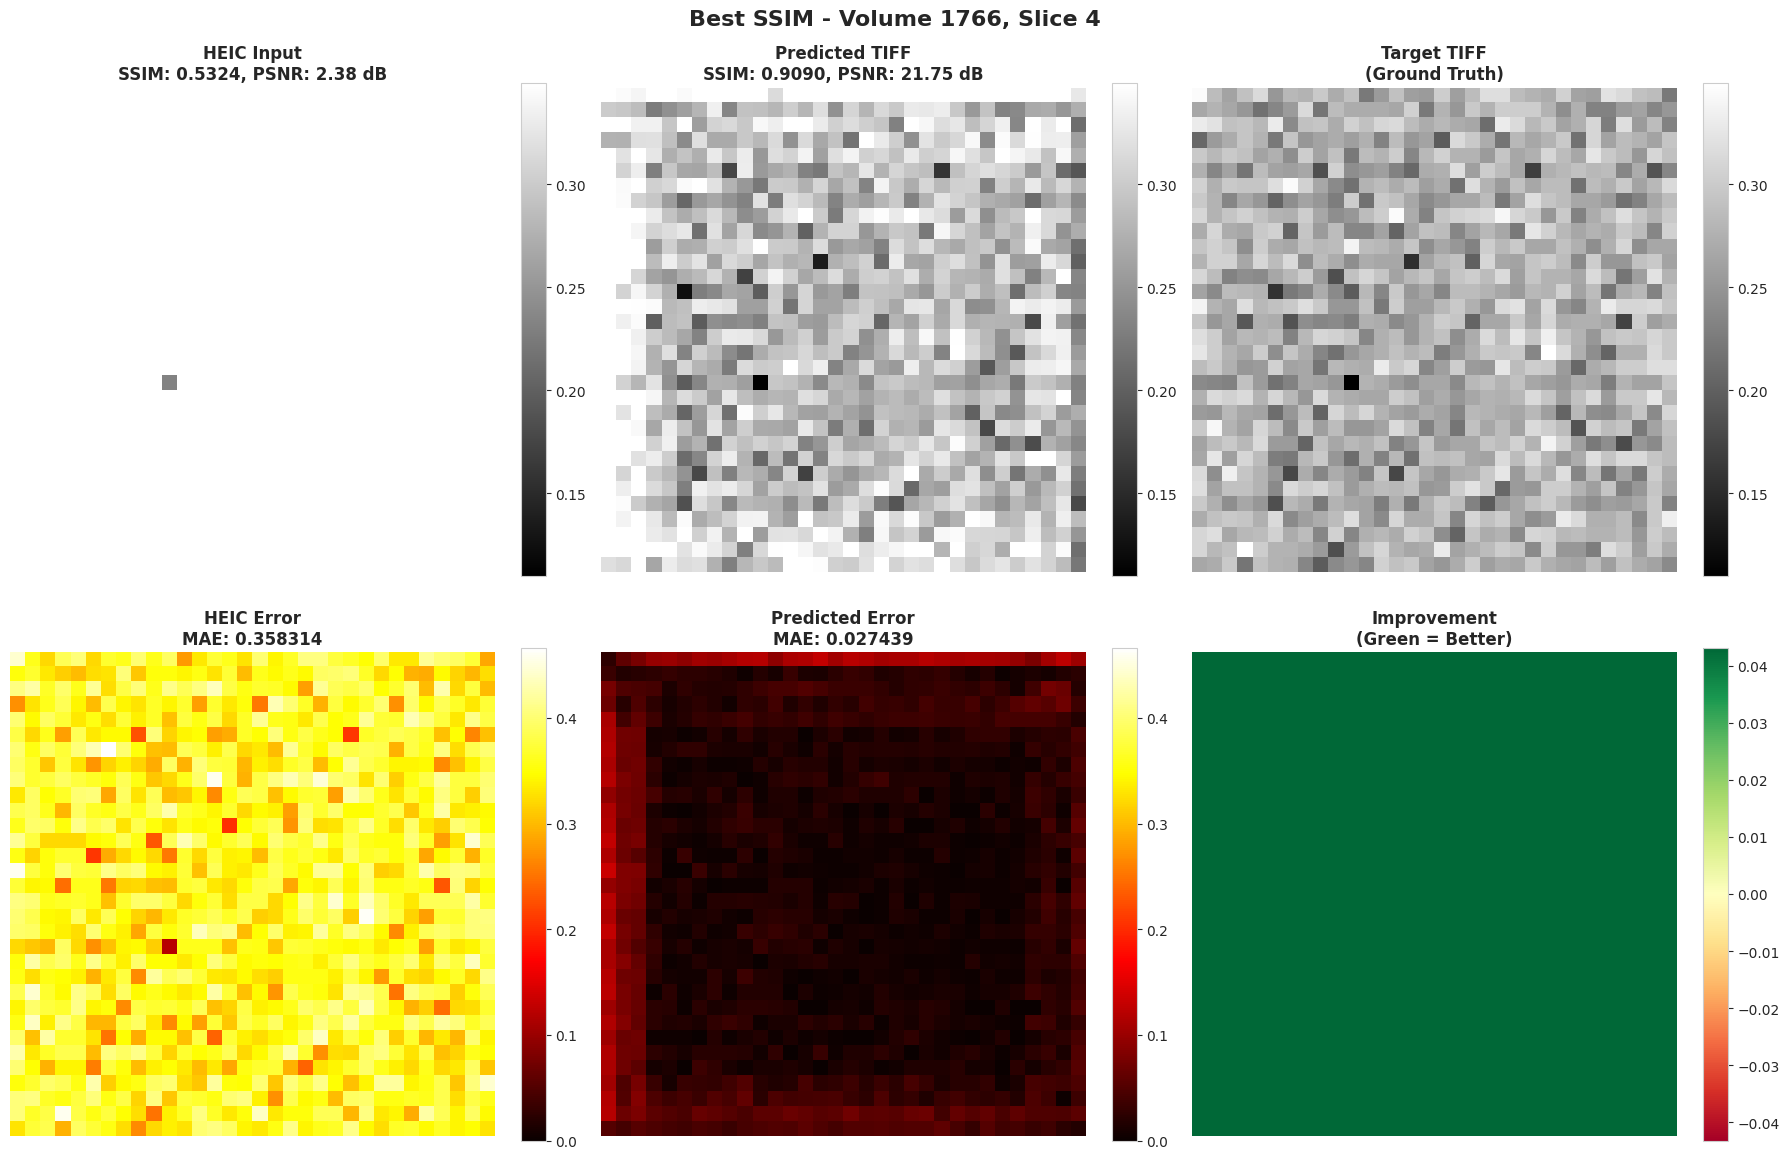

✓ Best SSIM visualization saved


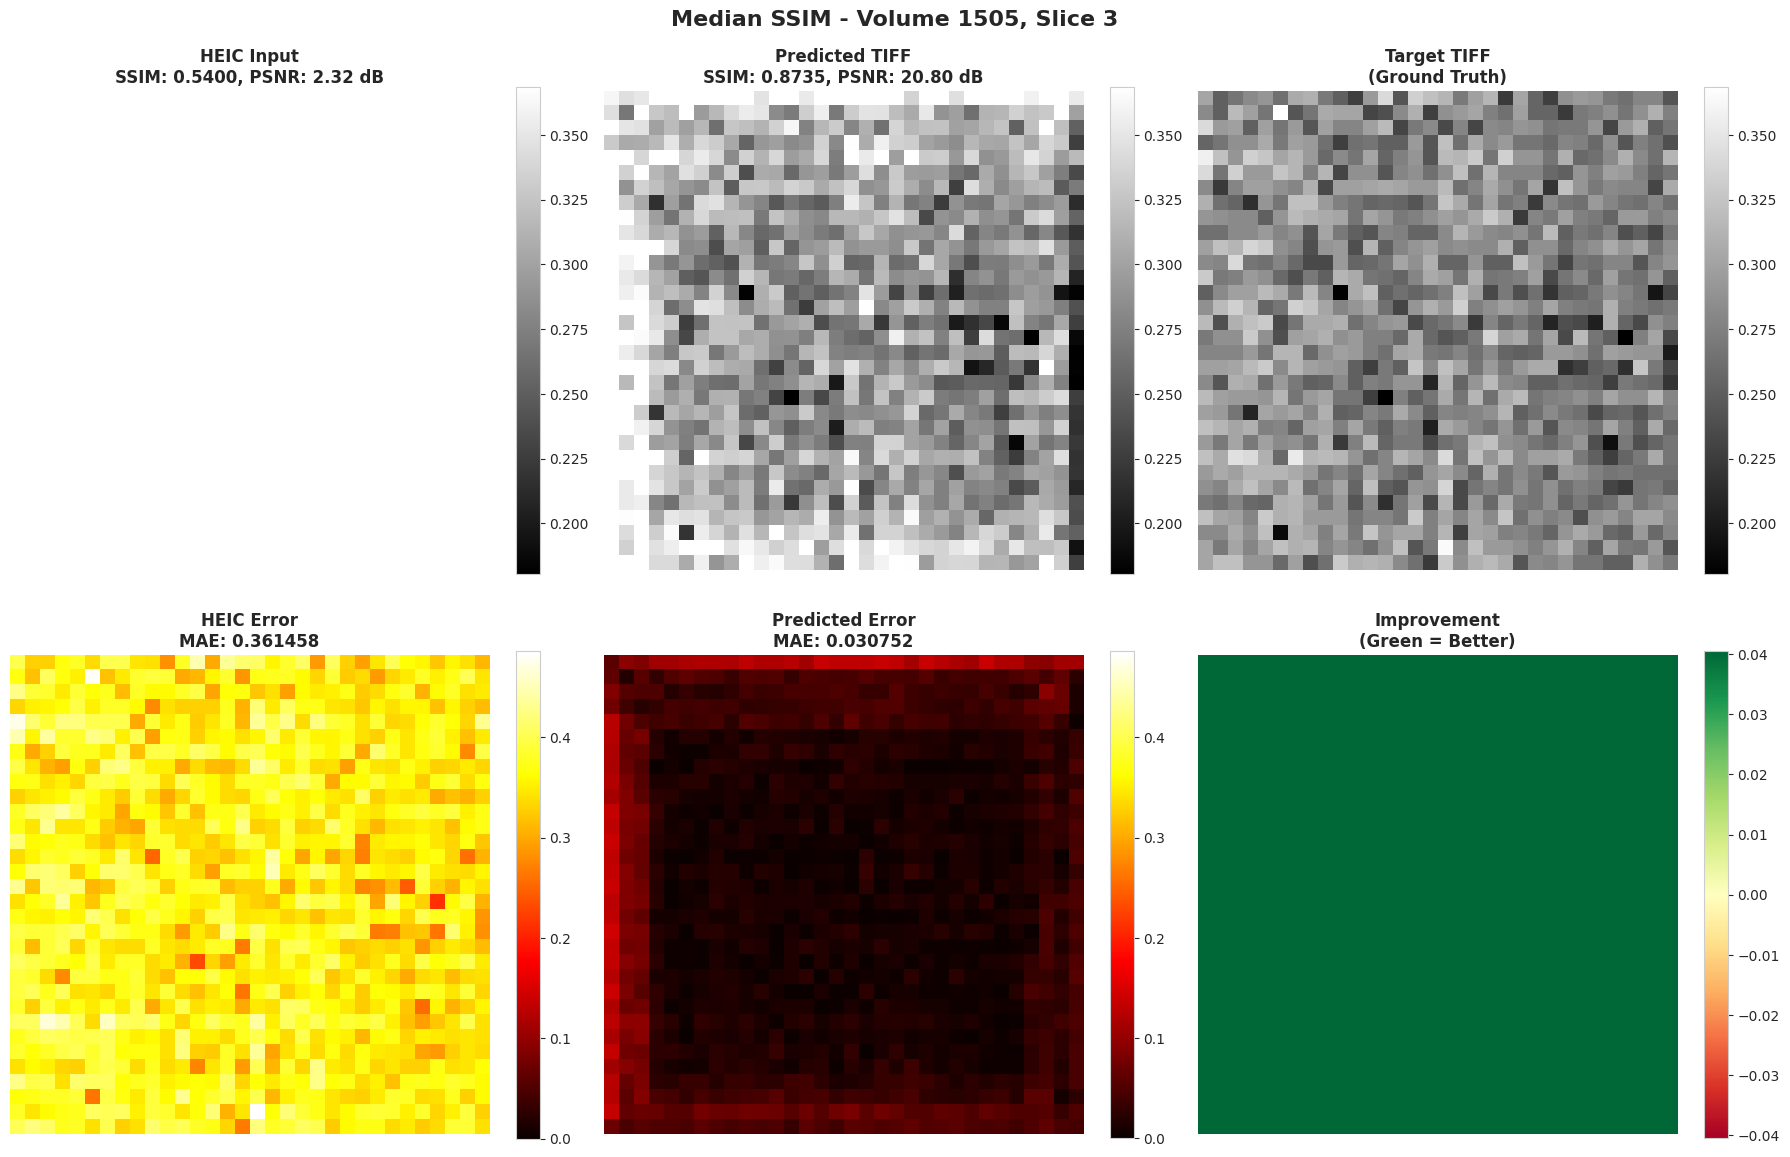

✓ Median SSIM visualization saved


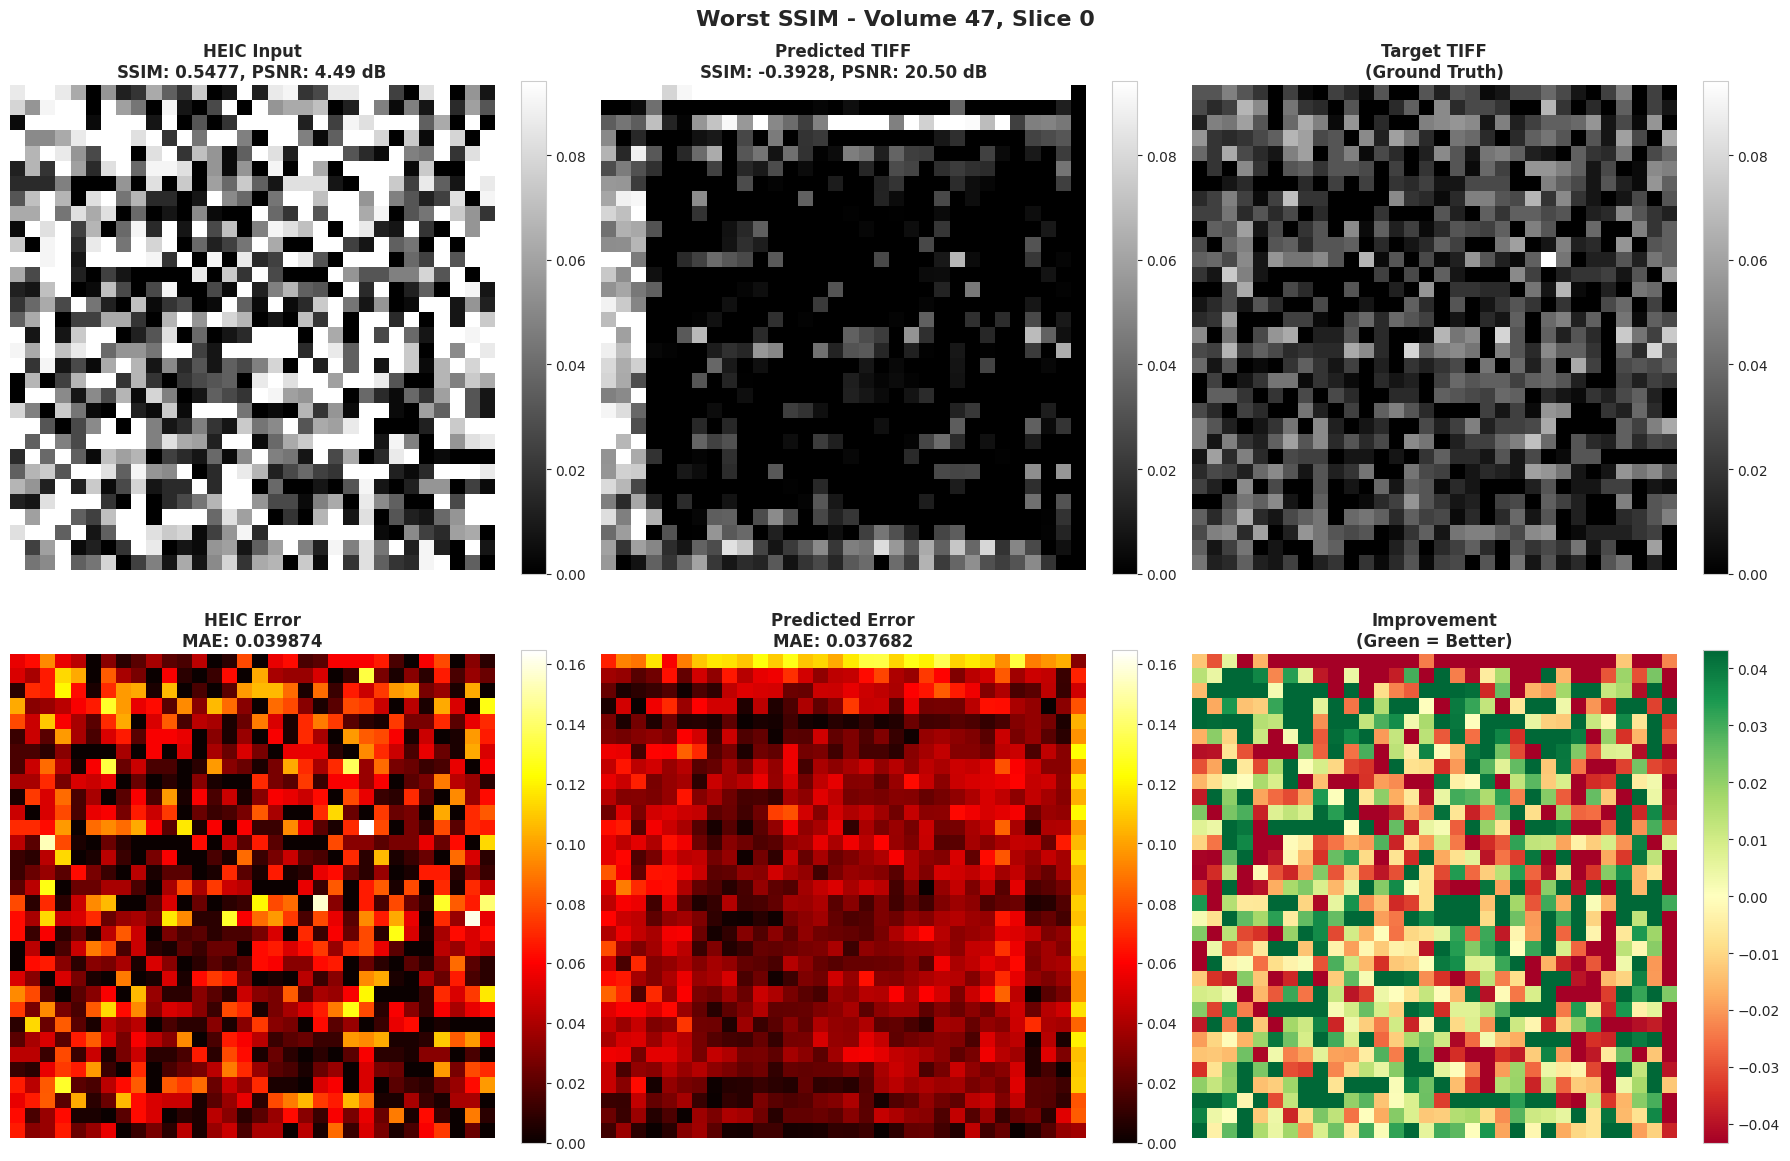

✓ Worst SSIM visualization saved


In [19]:
# Select diverse samples based on metrics
# Find: best SSIM, worst SSIM, median SSIM
best_idx = df_predicted['ssim'].idxmax()
worst_idx = df_predicted['ssim'].idxmin()
median_idx = df_predicted['ssim'].argsort().iloc[len(df_predicted)//2]

sample_indices = [
    ('Best SSIM', best_idx),
    ('Median SSIM', median_idx),
    ('Worst SSIM', worst_idx)
]

for sample_name, idx in sample_indices:
    vol_idx, slice_idx = df_predicted.loc[idx, 'slice_idx']
    
    # Extract slices
    heic_slice = inputs_np[vol_idx, slice_idx]
    pred_slice = predictions_np[vol_idx, slice_idx]
    target_slice = targets_np[vol_idx, slice_idx]
    
    # Get metrics
    pred_ssim = df_predicted.loc[idx, 'ssim']
    pred_psnr = df_predicted.loc[idx, 'psnr']
    heic_ssim = df_heic.loc[idx, 'ssim']
    heic_psnr = df_heic.loc[idx, 'psnr']
    
    # Compute differences
    heic_diff = np.abs(target_slice - heic_slice)
    pred_diff = np.abs(target_slice - pred_slice)
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Top row: Images
    im0 = axes[0, 0].imshow(heic_slice, cmap='gray', vmin=target_slice.min(), vmax=target_slice.max())
    axes[0, 0].set_title(f'HEIC Input\nSSIM: {heic_ssim:.4f}, PSNR: {heic_psnr:.2f} dB', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)
    
    im1 = axes[0, 1].imshow(pred_slice, cmap='gray', vmin=target_slice.min(), vmax=target_slice.max())
    axes[0, 1].set_title(f'Predicted TIFF\nSSIM: {pred_ssim:.4f}, PSNR: {pred_psnr:.2f} dB', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)
    
    im2 = axes[0, 2].imshow(target_slice, cmap='gray', vmin=target_slice.min(), vmax=target_slice.max())
    axes[0, 2].set_title('Target TIFF\n(Ground Truth)', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)
    
    # Bottom row: Difference maps
    diff_max = max(heic_diff.max(), pred_diff.max())
    
    im3 = axes[1, 0].imshow(heic_diff, cmap='hot', vmin=0, vmax=diff_max)
    axes[1, 0].set_title(f'HEIC Error\nMAE: {heic_diff.mean():.6f}', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)
    
    im4 = axes[1, 1].imshow(pred_diff, cmap='hot', vmin=0, vmax=diff_max)
    axes[1, 1].set_title(f'Predicted Error\nMAE: {pred_diff.mean():.6f}', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)
    
    # Improvement visualization
    improvement = heic_diff - pred_diff  # Positive = improvement
    im5 = axes[1, 2].imshow(improvement, cmap='RdYlGn', vmin=-improvement.std(), vmax=improvement.std())
    axes[1, 2].set_title(f'Improvement\n(Green = Better)', fontsize=12, fontweight='bold')
    axes[1, 2].axis('off')
    plt.colorbar(im5, ax=axes[1, 2], fraction=0.046)
    
    fig.suptitle(f'{sample_name} - Volume {vol_idx}, Slice {slice_idx}', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'reconstruction_{sample_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ {sample_name} visualization saved")

## 10. Save Results Summary

In [12]:
# Create summary report
summary = {
    'Configuration': config,
    'Dataset': {
        'Total sub-volumes': len(dataset),
        'Volume shape': dataset.volume.shape,
        'Total slices evaluated': len(slice_metrics),
    },
    'Predicted TIFF Metrics': {
        'SSIM': {
            'mean': float(df_predicted['ssim'].mean()),
            'std': float(df_predicted['ssim'].std()),
            'min': float(df_predicted['ssim'].min()),
            'max': float(df_predicted['ssim'].max()),
            'median': float(df_predicted['ssim'].median()),
        },
        'PSNR': {
            'mean': float(df_predicted['psnr'].mean()),
            'std': float(df_predicted['psnr'].std()),
            'min': float(df_predicted['psnr'].min()),
            'max': float(df_predicted['psnr'].max()),
            'median': float(df_predicted['psnr'].median()),
        },
    },
    'HEIC Baseline Metrics': {
        'SSIM': {
            'mean': float(df_heic['ssim'].mean()),
            'std': float(df_heic['ssim'].std()),
            'min': float(df_heic['ssim'].min()),
            'max': float(df_heic['ssim'].max()),
            'median': float(df_heic['ssim'].median()),
        },
        'PSNR': {
            'mean': float(df_heic['psnr'].mean()),
            'std': float(df_heic['psnr'].std()),
            'min': float(df_heic['psnr'].min()),
            'max': float(df_heic['psnr'].max()),
            'median': float(df_heic['psnr'].median()),
        },
    },
    'Improvement': {
        'SSIM': {
            'absolute': float(ssim_improvement),
            'relative_percent': float(ssim_improvement / df_heic['ssim'].mean() * 100),
        },
        'PSNR': {
            'absolute_dB': float(psnr_improvement),
            'relative_percent': float(psnr_improvement / df_heic['psnr'].mean() * 100),
        },
    },
}

# Save to JSON
import json
with open('evaluation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Evaluation summary saved to 'evaluation_summary.json'")

# Save detailed metrics to CSV
df_predicted.to_csv('predicted_metrics.csv', index=False)
df_heic.to_csv('heic_metrics.csv', index=False)

print("✓ Detailed metrics saved to CSV files")
print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)
print(f"\nGenerated files:")
print("  - evaluation_summary.json")
print("  - predicted_metrics.csv")
print("  - heic_metrics.csv")
print("  - heic_to_tiff_metrics_distribution.png")
print("  - reconstruction_*.png (sample visualizations)")

✓ Evaluation summary saved to 'evaluation_summary.json'


✓ Detailed metrics saved to CSV files

EVALUATION COMPLETE!

Generated files:
  - evaluation_summary.json
  - predicted_metrics.csv
  - heic_metrics.csv
  - heic_to_tiff_metrics_distribution.png
  - reconstruction_*.png (sample visualizations)
